# 손동작 MLP 학습 (Colab)

**전체 파이프라인**
1. 로컬에서 `collect_gesture_data.py`로 수집한 `gesture_features_index.csv`를 Google Drive에 업로드
2. 이 노트북으로 MLP 학습
3. Jetson(TF 2.4.1)용으로 **numpy 가중치(.npz)** + scaler 파라미터(json) + 라벨(json) 저장
   - `get_weights()` + `np.savez()` 방식은 Keras 버전 영향을 받지 않아
     Colab의 최신 TensorFlow에서 학습해도 Jetson의 구버전 TF에서 그대로 사용 가능

**미리 해둘 것**: `gesture_features_index.csv`를 Drive의
`MyDrive/hand_gesture/` 폴더에 업로드 (경로가 다르면 아래 CSV_PATH 수정)


## 1. Google Drive 마운트

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2. CSV 로드 및 데이터 확인

In [2]:
import numpy as np
import pandas as pd

CSV_PATH = '/content/drive/MyDrive/hand_gesture/gesture_features_index.csv'
SAVE_DIR = '/content/drive/MyDrive/hand_gesture/model_output'

# 수집 코드와 동일한 순서 (Jetson 추론 코드도 동일해야 함)
FEATURE_NAMES = [
    "wrist_dx", "wrist_dy", "index_dx", "index_dy",
    "pinch_delta", "pinch_speed", "duration",
    "wrist_speed_x", "wrist_speed_y", "index_speed_x", "index_speed_y",
    "pinch_min", "pinch_max",
]

df = pd.read_csv(CSV_PATH)
print('전체 데이터 개수:', len(df))
print()
print('클래스별 데이터 개수:')
print(df['label'].value_counts())


전체 데이터 개수: 800

클래스별 데이터 개수:
label
zoom_in        100
zoom_out       100
scroll_up      100
scroll_down    100
move_left      100
move_right     100
click          100
idle           100
Name: count, dtype: int64


## 3. 전처리 (라벨 인코딩 + 표준화)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

X = df[FEATURE_NAMES].values.astype(np.float32)
y = df['label'].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('학습:', X_train.shape, ' 테스트:', X_test.shape)
print('클래스 순서:', list(label_encoder.classes_))


학습: (640, 13)  테스트: (160, 13)
클래스 순서: ['click', 'idle', 'move_left', 'move_right', 'scroll_down', 'scroll_up', 'zoom_in', 'zoom_out']


## 4. MLP 모델 정의
Dense 레이어만 사용 - GPU 전용 특수 연산(LSTM의 CudnnRNNV3 같은 것)이 없어서
어떤 환경에서 학습해도 가중치가 순수 행렬로만 구성됩니다.


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print('TensorFlow:', tf.__version__)

# 이 구조는 Jetson 추론 코드(build_model)와 완전히 동일해야 함
model = Sequential([
    Input(shape=(len(FEATURE_NAMES),)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(num_classes, activation='softmax'),
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()


TensorFlow: 2.20.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,640 (14.22 KB)

 Trainable params: 3,640 (14.22 KB)

 Non-trainable params: 0 (0.00 B)

## 5. 학습

In [5]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1,
)


Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.1934 - loss: 2.0015 - val_accuracy: 0.4609 - val_loss: 1.8456
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5020 - loss: 1.6575 - val_accuracy: 0.6328 - val_loss: 1.4226
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6602 - loss: 1.2252 - val_accuracy: 0.8203 - val_loss: 0.9587
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7754 - loss: 0.8387 - val_accuracy: 0.9141 - val_loss: 0.5578
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9102 - loss: 0.5171 - val_accuracy: 1.0000 - val_loss: 0.2699
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9688 - loss: 0.2957 - val_accuracy: 1.0000 - val_loss: 0.1097
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9766 - loss: 0.1737 - val_accuracy: 1.0000 - val_loss: 0.0461
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9746 - loss: 0.1325 - val_accuracy: 1.000

## 6. 평가 (정확도 / 리포트 / 컨퓨전 매트릭스)

테스트 손실: 0.0000
테스트 정확도: 1.0000

Classification Report
              precision    recall  f1-score   support

       click       1.00      1.00      1.00        20
        idle       1.00      1.00      1.00        20
   move_left       1.00      1.00      1.00        20
  move_right       1.00      1.00      1.00        20
 scroll_down       1.00      1.00      1.00        20
   scroll_up       1.00      1.00      1.00        20
     zoom_in       1.00      1.00      1.00        20
    zoom_out       1.00      1.00      1.00        20

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160

Confusion Matrix
[[20  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0]
 [ 0  0  0  0 20  0  0  0]
 [ 0  0  0  0  0 20  0  0]
 [ 0  0  0  0  0  0 20  0]
 [ 0  0  0  0  0  0  0 20]]


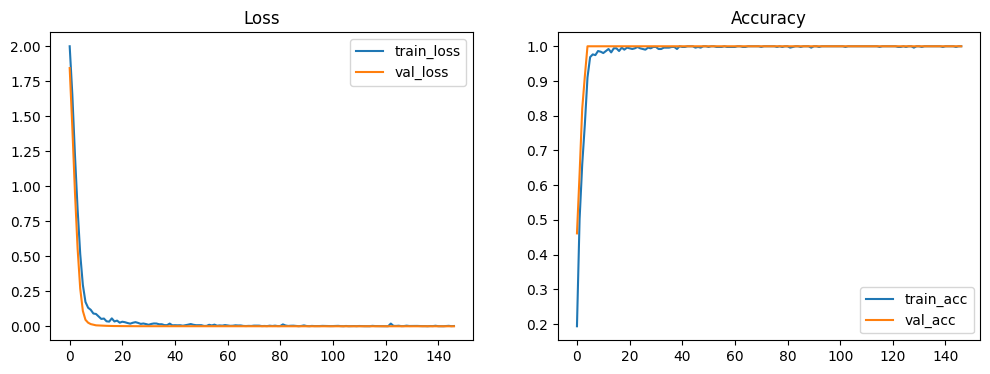

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'테스트 손실: {test_loss:.4f}')
print(f'테스트 정확도: {test_acc:.4f}')
print()

y_pred = model.predict(X_test, verbose=0).argmax(axis=1)

print('Classification Report')
print(classification_report(
    y_test, y_pred,
    labels=np.arange(num_classes),
    target_names=label_encoder.classes_,
    zero_division=0,
))

print('Confusion Matrix')
print(confusion_matrix(y_test, y_pred))

# 학습 곡선
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train_loss')
axes[0].plot(history.history['val_loss'], label='val_loss')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train_acc')
axes[1].plot(history.history['val_accuracy'], label='val_acc')
axes[1].set_title('Accuracy'); axes[1].legend()
plt.show()


## 7. Jetson용 저장 (npz 가중치 + scaler json + labels json)

- `gesture_weights.npz` : `get_weights()` + `np.savez()` — **Keras 버전 영향 없음** (Jetson TF 2.4.1용)
- `scaler_params.json` : StandardScaler의 mean/scale 숫자만 저장 — sklearn 버전 문제 회피 (Jetson에 sklearn 불필요)
- `labels.json` : 클래스 순서
- `gesture_mlp.h5` : (선택) 로컬 PC 검증용


In [7]:
import os, json

os.makedirs(SAVE_DIR, exist_ok=True)

# 1. numpy 가중치 저장 (Jetson용, Keras 버전 영향 없음)
weights = model.get_weights()
np.savez(os.path.join(SAVE_DIR, 'gesture_weights.npz'), *weights)
print(f'가중치 배열 {len(weights)}개 저장 완료 (gesture_weights.npz)')

# 2. StandardScaler 파라미터를 순수 숫자(json)로 저장
scaler_params = {
    'mean': scaler.mean_.tolist(),
    'scale': scaler.scale_.tolist(),
}
with open(os.path.join(SAVE_DIR, 'scaler_params.json'), 'w', encoding='utf-8') as f:
    json.dump(scaler_params, f, indent=2)
print('scaler_params.json 저장 완료')

# 3. 라벨(클래스 순서) 저장
labels = {i: name for i, name in enumerate(label_encoder.classes_)}
with open(os.path.join(SAVE_DIR, 'labels.json'), 'w', encoding='utf-8') as f:
    json.dump(labels, f, ensure_ascii=False, indent=2)
print('labels.json 저장 완료:', labels)

# 4. (선택) 로컬 PC 검증용 h5
model.save(os.path.join(SAVE_DIR, 'gesture_mlp.h5'), save_format='h5')
print('gesture_mlp.h5 저장 완료 (로컬 검증용)')

print()
print('저장 위치:', SAVE_DIR)
print(os.listdir(SAVE_DIR))
print()
print('Jetson에 넘길 파일: gesture_weights.npz, scaler_params.json, labels.json')


가중치 배열 8개 저장 완료 (gesture_weights.npz)
scaler_params.json 저장 완료
labels.json 저장 완료: {0: 'click', 1: 'idle', 2: 'move_left', 3: 'move_right', 4: 'scroll_down', 5: 'scroll_up', 6: 'zoom_in', 7: 'zoom_out'}
gesture_mlp.h5 저장 완료 (로컬 검증용)

저장 위치: /content/drive/MyDrive/hand_gesture/model_output
['gesture_weights.npz', 'scaler_params.json', 'labels.json', 'gesture_mlp.h5']

Jetson에 넘길 파일: gesture_weights.npz, scaler_params.json, labels.json
